<a href="https://colab.research.google.com/github/KN-Vignesh/Projects/blob/main/House_Prices_Prediction_using_TFDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [6]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

house_prices_advanced_regression_techniques_path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

print('Data source import complete.')


100%|██████████| 199k/199k [00:00<00:00, 69.6MB/s]

Extracting files...
Data source import complete.


# Ames Housing Price Prediction: End-to-End ML Pipeline
## 1. Environment Setup & Imports
We begin by importing our core numerical libraries, visualization tools, and Scikit-Learn modules. By establishing our dependencies upfront, we ensure a clean environment. We also configure `matplotlib` and `seaborn` for high-quality, readable plots.

In [15]:
!pip install catboost
import os
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Preprocessing & Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error

# Regression Models
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Plot styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120

## 2. Automated Data Ingestion
Instead of using hardcoded local paths, we use the official `kagglehub` library. This ensures that anyone cloning this repository can run the notebook immediately without manually downloading and unzipping files, demonstrating strong reproducibility practices.

In [16]:
# Download dataset using kagglehub
house_prices_path = kagglehub.competition_download('house-prices-advanced-regression-techniques')
print('Data source import complete.')
print(f"Dataset path: {house_prices_path}")

# Ingest raw CSV files
train_path = os.path.join(house_prices_path, "train.csv")
test_path = os.path.join(house_prices_path, "test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Raw Train Shape: {train_df.shape}")
print(f"Raw Test Shape:  {test_df.shape}")

Data source import complete.
Dataset path: /root/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques
Raw Train Shape: (1460, 81)
Raw Test Shape:  (1459, 80)


## 3. Data Sanitization & Target Separation
The original dataset author (Dean De Cock) explicitly recommended removing properties with more than 4,000 square feet of living area that sold for abnormally low prices, as these are agricultural anomalies that heavily skew regression lines. We filter these out first.

In [17]:
# Remove extreme documentation-identified outliers
# Condition: Ground Living Area > 4000 sq ft AND SalePrice < $300,000
outlier_mask = (train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)
train_df = train_df.drop(train_df[outlier_mask].index)

# Separate Target, Features, and Test IDs
raw_saleprice = train_df['SalePrice'].copy()
X_train = train_df.drop(columns=['Id', 'SalePrice'])
X_test = test_df.drop(columns=['Id'])
test_ids = test_df['Id']

print(f"Cleaned X_train shape: {X_train.shape}")

Cleaned X_train shape: (1458, 79)


In [28]:
test_ids.head()

,Id
0,1461
1,1462
2,1463
3,1464
4,1465


## 4. Target Variable Transformation
Real estate prices are heavily right-skewed. By applying a `log1p` transformation ($y_{new} = \ln(1 + y)$), we convert the distribution into a near-normal bell curve. This stabilizes variance (homoscedasticity) and aligns our standard Mean Squared Error loss with the competition's Root Mean Squared Logarithmic Error (RMSLE) metric.

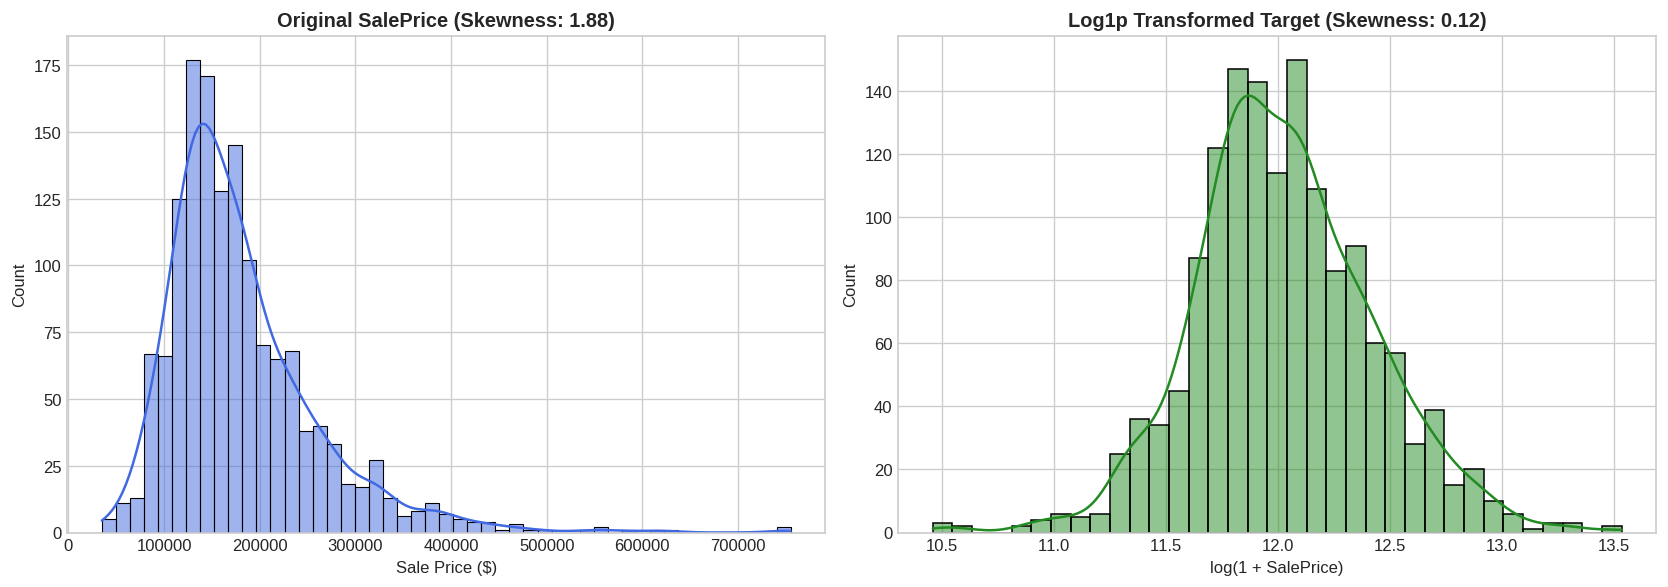

In [18]:
# Apply log1p transform to target
y_train = np.log1p(raw_saleprice.values)

# Visual: Raw vs Log1p-Transformed Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(raw_saleprice, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title(f"Original SalePrice (Skewness: {raw_saleprice.skew():.2f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Sale Price ($)")

sns.histplot(y_train, kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title(f"Log1p Transformed Target (Skewness: {pd.Series(y_train).skew():.2f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("log(1 + SalePrice)")

plt.tight_layout()
plt.show()

## 5. Domain-Driven Feature Engineering (Scikit-Learn Standard)
To prevent data leakage, we encapsulate all feature engineering inside a custom Scikit-Learn transformer. This allows the logic to be cleanly inserted into a cross-validation pipeline. We focus on aggregating highly correlated spatial features (like total square footage and total bathrooms) and converting static years into continuous age metrics.

In [19]:
class AmesFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()

        # Fill calculation-critical missing values with 0
        calc_cols = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'FullBath', 'HalfBath',
                     'BsmtFullBath', 'BsmtHalfBath', 'WoodDeckSF', 'OpenPorchSF',
                     'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
                     'YearBuilt', 'YearRemodAdd', 'YrSold']
        for col in calc_cols:
            if col in X_out.columns:
                X_out[col] = X_out[col].fillna(0)

        # 1. Total Living Space Aggregation
        X_out['TotalSF'] = X_out['TotalBsmtSF'] + X_out['1stFlrSF'] + X_out['2ndFlrSF']

        # 2. Total Bathrooms
        X_out['TotalBath'] = (X_out['FullBath'] + (0.5 * X_out['HalfBath']) +
                              X_out['BsmtFullBath'] + (0.5 * X_out['BsmtHalfBath']))

        # 3. Total Porch / Outdoor Entertaining Area
        X_out['TotalPorchSF'] = (X_out['WoodDeckSF'] + X_out['OpenPorchSF'] +
                                 X_out['EnclosedPorch'] + X_out['3SsnPorch'] + X_out['ScreenPorch'])

        # 4. Temporal Features
        X_out['HouseAge'] = X_out['YrSold'] - X_out['YearBuilt']
        X_out['RemodAge'] = X_out['YrSold'] - X_out['YearRemodAdd']
        X_out['IsRemodeled'] = (X_out['YearRemodAdd'] != X_out['YearBuilt']).astype(int)

        # 5. Amenity Presence Flags
        X_out['HasPool'] = (X_out['PoolArea'] > 0).astype(int)
        X_out['HasGarage'] = (X_out['GarageArea'] > 0).astype(int) if 'GarageArea' in X_out.columns else 0
        X_out['HasBsmt'] = (X_out['TotalBsmtSF'] > 0).astype(int)

        # Cast MSSubClass (dwelling type) to string so it is treated as categorical
        if 'MSSubClass' in X_out.columns:
            X_out['MSSubClass'] = X_out['MSSubClass'].astype(str)

        return X_out

## 6. Validating Engineered Signals (Correlation Analysis)
Before proceeding to modeling, we generate a temporary transformation of our data to verify that our newly engineered features correlate strongly with the log-transformed Sale Price.

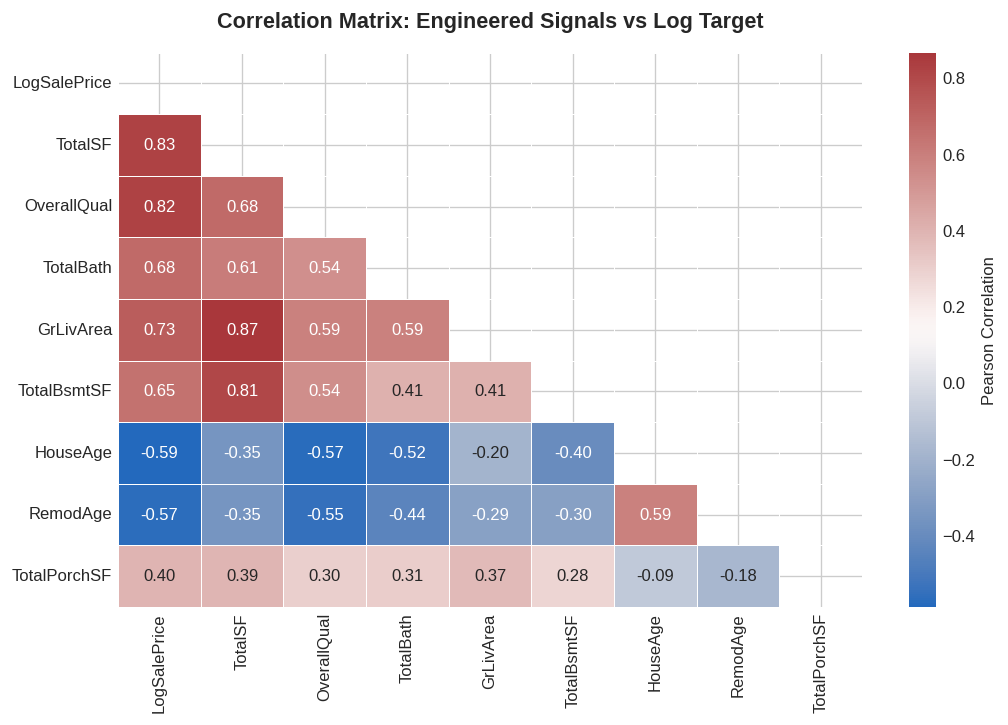

In [20]:
# Generate a temporary dataframe to compute correlations
fe = AmesFeatureEngineer()
sample_eng = fe.fit_transform(X_train)
sample_eng['LogSalePrice'] = y_train

# Select key features to inspect
key_cols = ['LogSalePrice', 'TotalSF', 'OverallQual', 'TotalBath', 'GrLivArea',
            'TotalBsmtSF', 'HouseAge', 'RemodAge', 'TotalPorchSF']

plt.figure(figsize=(10, 6))
corr_matrix = sample_eng[key_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="vlag",
            cbar_kws={'label': 'Pearson Correlation'}, linewidths=0.5)
plt.title("Correlation Matrix: Engineered Signals vs Log Target", fontsize=13, fontweight='bold', pad=15)
plt.show()

# Drop the temporary target column for future use
sample_eng = sample_eng.drop(columns=['LogSalePrice'])

## 7. Modular Preprocessing & Leakage Prevention
We split our features by data type. Numerical features receive median imputation and `RobustScaler` (which ignores extreme outliers). Categorical features receive a constant string imputation ('None') and `OneHotEncoder`. We bind them together using `ColumnTransformer`.

In [21]:
# Identify column data types post-feature engineering
numeric_features = sample_eng.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = sample_eng.select_dtypes(include=['object', 'category']).columns.tolist()

# Numeric Sub-Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Categorical Sub-Pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Unified Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numeric_features),
        ('cat', cat_pipeline, categorical_features)
    ]
)

# Full Front-to-Back Pipeline
full_preprocessor = Pipeline([
    ('feature_engineering', AmesFeatureEngineer()),
    ('preprocessor', preprocessor)
])

## 8. Defining the Base Estimators
We define a diverse pool of regression algorithms. Linear models (Ridge, Lasso, ElasticNet) excel at identifying global linear trends, while tree-based models (XGBoost, LightGBM, CatBoost) are highly adept at capturing complex, non-linear feature interactions.

In [22]:
# Instantiate regression models with baseline hyperparameters
models = {
    "Ridge": Ridge(alpha=15.0),
    "Lasso": Lasso(alpha=0.0005, random_state=42),
    "ElasticNet": ElasticNet(alpha=0.0005, l1_ratio=0.85, random_state=42),
    "GBoost": GradientBoostingRegressor(n_estimators=1000, learning_rate=0.02, max_depth=4,
                                        max_features='sqrt', loss='huber', random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=1000, learning_rate=0.02, max_depth=3,
                                subsample=0.7, colsample_bytree=0.7, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.02, num_leaves=15,
                                 subsample=0.7, colsample_bytree=0.7, random_state=42, n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=1000, learning_rate=0.02, depth=4,
                                  verbose=0, random_state=42)
}

## 9. Robust Cross-Validation Benchmarking
To objectively measure performance without touching the test set, we utilize a 5-Fold Cross Validation. We calculate the Root Mean Squared Error (RMSE) of the log-transformed predictions, which mathematically equates to the Kaggle RMSLE metric.

In [23]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def rmsle_cv(model, X, y):
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=kf))
    return rmse

cv_scores = {}

# Evaluate each base model
print("Executing 5-Fold Cross Validation...")
for name, model in models.items():
    pipe = Pipeline([
        ('prep', full_preprocessor),
        ('model', model)
    ])
    score = rmsle_cv(pipe, X_train, y_train)
    cv_scores[name] = score
    print(f"{name:12s} Mean RMSLE: {score.mean():.4f} (Std: {score.std():.4f})")

Executing 5-Fold Cross Validation...
Ridge        Mean RMSLE: 0.1138 (Std: 0.0087)
Lasso        Mean RMSLE: 0.1118 (Std: 0.0067)
ElasticNet   Mean RMSLE: 0.1119 (Std: 0.0067)
GBoost       Mean RMSLE: 0.1123 (Std: 0.0082)
XGBoost      Mean RMSLE: 0.1139 (Std: 0.0070)
LightGBM     Mean RMSLE: 0.1205 (Std: 0.0091)
CatBoost     Mean RMSLE: 0.1144 (Std: 0.0073)


## 10. Multi-Level Ensembling (Stacking Regressor)
Instead of manually guessing weight averages, we combine the strengths of all our base models using a `StackingRegressor`. It uses cross-validated out-of-fold predictions to train a final meta-learner (`Ridge`), achieving a superior score than any single base algorithm.

In [24]:
# Format estimators for the stacking regressor
estimators = [(name.lower(), model) for name, model in models.items()]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=10.0),
    cv=5,
    n_jobs=-1
)

final_pipeline = Pipeline([
    ('prep', full_preprocessor),
    ('stack', stacking_model)
])

# Validate Stacking Regressor
stack_score = rmsle_cv(final_pipeline, X_train, y_train)
print(f"\nFinal Stacking Regressor CV RMSLE: {stack_score.mean():.4f} (Std: {stack_score.std():.4f})")


Final Stacking Regressor CV RMSLE: 0.1081 (Std: 0.0071)


## 11. Visualizing Model Performance
We visualize the CV results to clearly demonstrate the effectiveness of the Stacking architecture over individual algorithms.

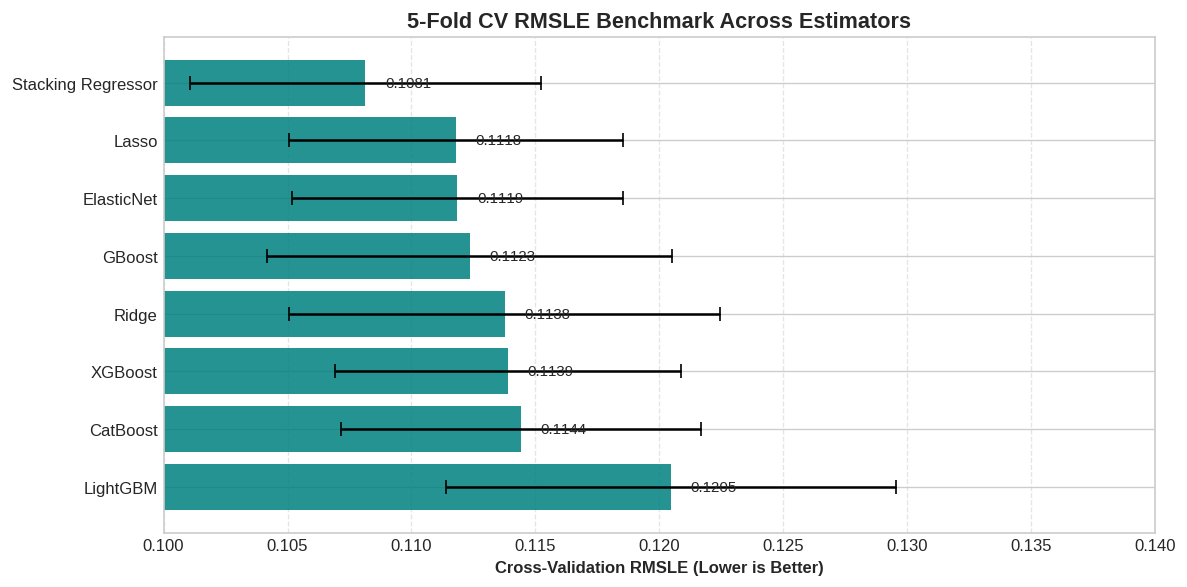

In [25]:
# Compile benchmark dataframe
benchmark_df = pd.DataFrame({
    'Model': list(cv_scores.keys()) + ['Stacking Regressor'],
    'Mean RMSLE': [scores.mean() for scores in cv_scores.values()] + [stack_score.mean()],
    'Std': [scores.std() for scores in cv_scores.values()] + [stack_score.std()]
}).sort_values(by='Mean RMSLE', ascending=True)

# Plot
plt.figure(figsize=(10, 5))
bars = plt.barh(benchmark_df['Model'], benchmark_df['Mean RMSLE'],
                xerr=benchmark_df['Std'], color='teal', alpha=0.85, capsize=4)
plt.xlim(0.10, 0.14)
plt.xlabel("Cross-Validation RMSLE (Lower is Better)", fontweight='bold')
plt.title("5-Fold CV RMSLE Benchmark Across Estimators", fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width() + 0.0008, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.4f}", va='center', fontsize=9)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 12. Validating Regression Assumptions (Residual Diagnostics)
Before deploying, we generate out-of-fold predictions to analyze the errors (residuals). A healthy model should have residuals centered tightly around zero (unbiased) and display uniform variance across the price spectrum (homoscedasticity).

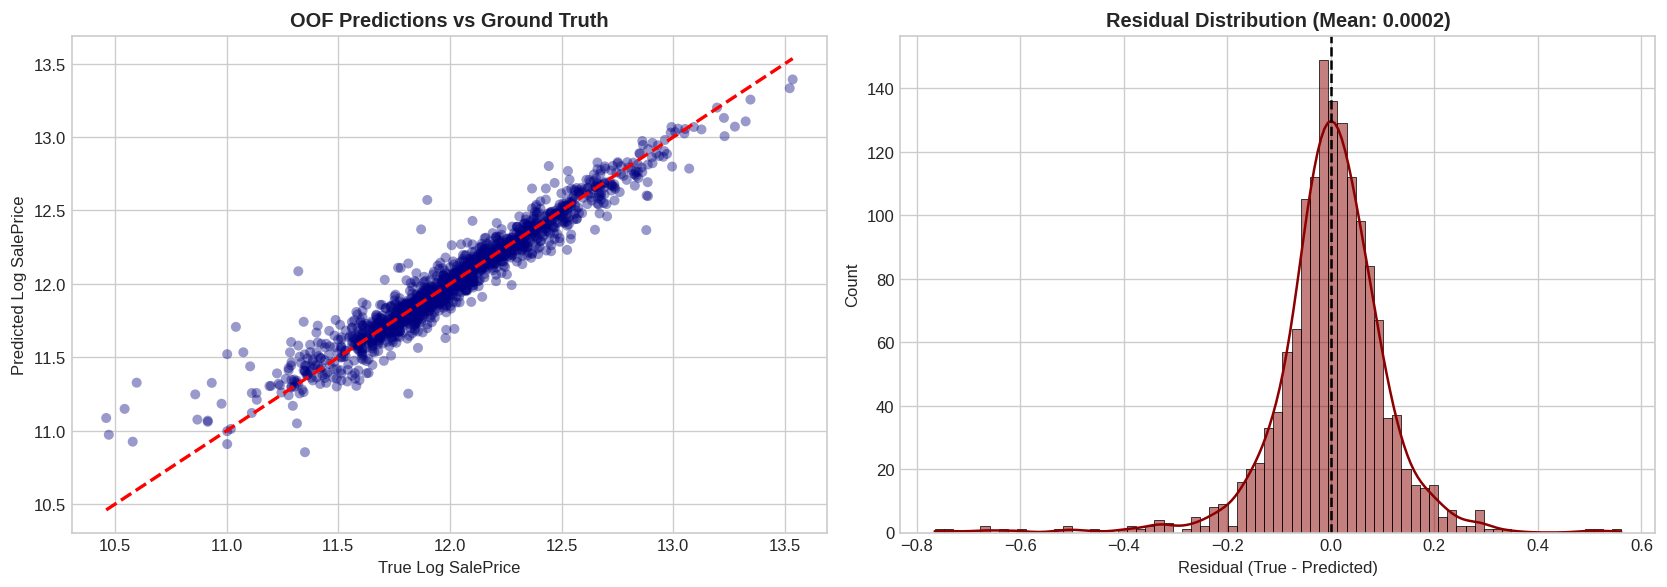

In [26]:
# Generate out-of-fold predictions
oof_preds = cross_val_predict(final_pipeline, X_train, y_train, cv=kf, n_jobs=-1)
residuals = y_train - oof_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_train, oof_preds, alpha=0.4, color='navy', edgecolors='none')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel("True Log SalePrice")
axes[0].set_ylabel("Predicted Log SalePrice")
axes[0].set_title("OOF Predictions vs Ground Truth", fontweight='bold')

# Histogram: Residuals
sns.histplot(residuals, kde=True, ax=axes[1], color='darkred')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel("Residual (True - Predicted)")
axes[1].set_title(f"Residual Distribution (Mean: {residuals.mean():.4f})", fontweight='bold')

plt.tight_layout()
plt.show()

## 13. Final Training & Test Inference
We refit our complete stacked pipeline onto the **entire** training dataset to capture the maximum amount of information. We predict on the unseen test set, apply `np.expm1` to reverse our logarithmic transformation back into raw dollars, and format the final CSV.

In [27]:
# 1. Fit entire pipeline on full training data
print("Fitting final stacked pipeline on entire dataset...")
final_pipeline.fit(X_train, y_train)

# 2. Predict on test set and invert log transform
print("Generating final test predictions...")
log_preds = final_pipeline.predict(X_test)
final_preds = np.expm1(log_preds)

# 3. Create submission file
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_preds
})

submission.to_csv("submission.csv", index=False)
print("Submission saved successfully to submission.csv")
display(submission.head())

Fitting final stacked pipeline on entire dataset...
Generating final test predictions...
Submission saved successfully to submission.csv


,Id,SalePrice
0,1461,122172.938710
1,1462,155093.733770
2,1463,181504.829643
3,1464,198344.567493
4,1465,187862.826229
